In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [ ]:
from PIL import Image
import pytesseract

# Path to the image file
image_path = r"D:\Piyush\Pictures\Hands-on Quiz - Linear Regression.jpg"

# Load the image
image = Image.open(image_path)

# Perform OCR on the image
ocr_text = pytesseract.image_to_string(image)

# Print the extracted text
print(ocr_text)


#### Please download and import the dataset insurance.csv into Jupyter Notebook to attempt this quiz.

#### Problem Statement:
Medicalnsure is a medical insurance provider. Leveraging customer information is of paramount importance for most businesses. In the case of an insurance company, analysis of customer attributes like
age, sex, smoking habits, etc. can be crucial in making decisions regarding the premium amount to be charged.

#### Attribute information:

. age: age of the policyholder

. sex: gender of the policyholder

. bmi: Body Mass Index of the policyholder

. children: number of children of the policyholder

. smoker: whether the policyholder is a smoker or not
. region: region where the policyholder belongs to

. charges: premium charged to the policyholder

NOOB WN

#### Kindly go through these guidelines before you attempt the quiz:

1. Use random_state=1 wherever this parameter can be used.

2. Import pandas as pd, numpy as np, seaborn as sns, and matplotlib.pyplot and pit at the start.

3. Ensure there is a proper internet connection while taking the quiz. Any breakup in the connection will automatically submit your quiz.

4. Only attempt the quiz when you are prepared and have enough time on your hands to finish it. Please ensure you try the quiz well before the due date. No extension will be provided for any quiz once
the deadline has passed.

. The quiz once opened, must be completed within the time frame provided. You CANNOT start the quiz, leave it unattended for an extended period, and return later to finish.

. No re-attempts will be provided if the quiz gets submitted for any of the above-mentioned reasons.

7. If you face any other technical issues on Olympus, you should share the screenshot with your program manager so that the team can understand and resolve them as soon as possible.


In [6]:
# Load the dataset
insurance_data = pd.read_csv('insurance.csv')

# Display the first few rows of the dataset
print("First 5 rows of the dataset:")
print(insurance_data.head())

# Display basic information about the dataset
print("\nDataset Information:")
print(insurance_data.info())

# Display summary statistics of the dataset
print("\nSummary Statistics:")
print(insurance_data.describe())

# Check for missing values
print("\nMissing Values:")
print(insurance_data.isnull().sum())

# Display the column names
print("\nColumn Names:")
print(insurance_data.columns)

First 5 rows of the dataset:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Summary Statistics:
               age 

In [22]:
df = insurance_data.copy()
df.shape

(1338, 7)

In [23]:
missing_charges = df['charges'].isnull().sum()
print(f"Number of missing values in 'charges' column: {missing_charges}")

Number of missing values in 'charges' column: 0


In [24]:
# Apply log transformation to the 'bmi' column
df['log_bmi'] = np.log(df['bmi'])

# Display the first few rows to verify the transformation
print(df[['bmi', 'log_bmi']].head())

      bmi   log_bmi
0  27.900  3.328627
1  33.770  3.519573
2  33.000  3.496508
3  22.705  3.122585
4  28.880  3.363149


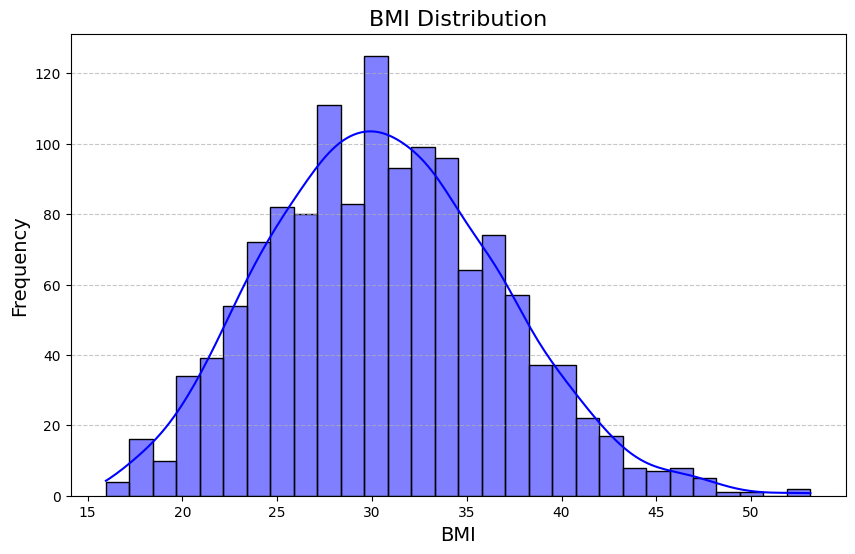

In [10]:
# Plot a histogram for BMI distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['bmi'], kde=True, bins=30, color='blue')
plt.title('BMI Distribution', fontsize=16)
plt.xlabel('BMI', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [11]:
# Group by region and calculate the median insurance charges
median_charges_by_region = df.groupby('region')['charges'].median()

# Find the region with the highest median charges
highest_median_region = median_charges_by_region.idxmax()
highest_median_value = median_charges_by_region.max()

print(f"The region with the highest median insurance charges is '{highest_median_region}' with a median charge of {highest_median_value:.2f}.")

The region with the highest median insurance charges is 'northeast' with a median charge of 10057.65.


In [12]:
correlation_age_charges = df['age'].corr(df['charges'])
print(f"Correlation between age and charges: {correlation_age_charges:.2f}")

Correlation between age and charges: 0.30


In [13]:
# Create dummy variables for categorical columns
df_dummies = pd.get_dummies(df, drop_first=True)

# List the dropped dummy variables for the 'region' column
dropped_region = df['region'].unique()[0]
print(f"The dummy variable dropped for the 'region' column is: '{dropped_region}'")

The dummy variable dropped for the 'region' column is: 'southwest'


In [ ]:
# Create dummy variables for categorical columns
df_dummies_2 = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# List the dropped dummy variables for the 'region' column
df_dummies_2.head()


,age,bmi,children,charges,log_bmi,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,3.328627,False,True,False,False,True
1,18,33.770,1,1725.55230,3.519573,True,False,False,True,False
2,28,33.000,3,4449.46200,3.496508,True,False,False,True,False
3,33,22.705,0,21984.47061,3.122585,True,False,True,False,False
4,32,28.880,0,3866.85520,3.363149,True,False,True,False,False


In [26]:
dropped_region = df['region'].unique()[0]
print(f"The dummy variable dropped for the 'region' column is: '{dropped_region}'")

The dummy variable dropped for the 'region' column is: 'southwest'


In [14]:
from sklearn.model_selection import train_test_split

# Drop the 'log_bmi' column
df = df.drop(columns=['log_bmi'])

# Split the data into train and test sets (70:30 ratio)
train_set, test_set = train_test_split(df, test_size=0.3, random_state=1)

# Print the number of rows in the test set
print(f"Number of rows in the test set: {test_set.shape[0]}")

Number of rows in the test set: 402


In [15]:
from sklearn.linear_model import LinearRegression

# Prepare the features (X) and target (y) for training
X_train = pd.get_dummies(train_set.drop(columns=['charges']), drop_first=True)
y_train = train_set['charges']

# Initialize and train the linear regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Print the intercept value
print(f"Intercept value: {linear_model.intercept_}")

Intercept value: -11039.238418561557


In [16]:
# Calculate the R-squared value
r_squared = linear_model.score(X_train, y_train)

# Print the R-squared value
print(f"R-squared value: {r_squared:.4f}")

R-squared value: 0.7546


In [17]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Prepare the features (X_test) and target (y_test) for the test set
X_test = pd.get_dummies(test_set.drop(columns=['charges']), drop_first=True)
y_test = test_set['charges']

# Make predictions on the test set
y_pred = linear_model.predict(X_test)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE on the test set: {rmse:.2f}")

RMSE on the test set: 6063.12


In [18]:
from sklearn.metrics import mean_absolute_error

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE on the test set: {mae:.2f}")

MAE on the test set: 4139.93
